The main point of this notebook is to demonstrate a few tools for segmenting images of solar granulation.  From there, a bunch of things can be calculated (area, excentricity, etc.).  I started doing some simple estimates shear flows as well, with the aim of studying kelvin helmholtz instability, and compared a few different ways to calculate the circulation around granules.  Not sure where that calculation is going yet.

In [1]:
import numpy as np # mathematical tools
import matplotlib.pyplot as plt # plotting figures tools
import glob, sys, os # packages for handling files, dealing with system call

import tesselation_module as tess # module with scripts to tesselate and label an image
import h5py # handle hdf5 format 
from scipy import ndimage as ndi
import skimage as ski
from skimage.measure import regionprops
from skimage.morphology import remove_small_holes
from skimage.segmentation import expand_labels
from tqdm.notebook import tqdm
from scipy.integrate import simpson
# use in jupyter notebook only
%matplotlib widget 

## getting data

First you need to grab some muram data.  The following grabs a single output from the 200G run of the spin4d project, including forward modeled spectra of the FeI 6301/6302 lines:

<code>get_one_time.sh:
!# /bin/sh
SOURCE="http://dtn-itc.ifa.hawaii.edu/spin4d/DR1/SPIN4D_SSD_200G/"
for file in $(curl -s ${SOURCE} | grep href|sed 's/.*href="//'|sed 's/".*//'|grep '.070857'|grep 'subdomain')
do
    curl -s -O ${SOURCE}${file}
    #echo ${SOURCE}${file}
done
<code>

Other details of the data:

<code>
Pulled from http://dtn-itc.ifa.hawaii.edu/spin4d/DR1/
Case SPIN4D_SSD_200G
size: 1536x1536x720
Abbrev 	File Name 	File Parameter
rho 	subdomain_0 	density
vx 	subdomain_1 	velocity_x
vy 	subdomain_2 	velocity_y
vz 	subdomain_3 	velocity_z
eint 	subdomain_4 	internal electron pressure
Bx 	subdomain_5 	magnetic field_x
By 	subdomain_6 	magnetic field_y
Bz 	subdomain_7 	magnetic field_z
T 	subdomain_8 	temperature
P 	subdomain_9 	pressure
ne 	subdomain_10 	number of electrons
tau500 	subdomain_11 	opacity at 500nm
<code>

## load the stokes file, and create a continuum intensity image
We'll use this to define the granulation cells and boundaries.

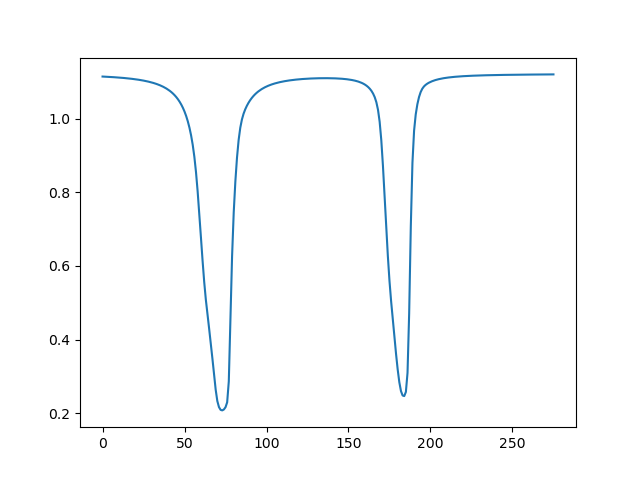

In [2]:
# Load the stokes file for one of the timesteps
sf = h5py.File('stokes-070857-6302.h5')

# intensity is in sf['I'].  Plot intensity in one pixel:
fig, ax = plt.subplots()
ax.plot(sf['I'][0,0,:])

Wavelength position 200 is in the contiuum, we'll define the granulation cells and boundaries at that wavelength.
Work with normalized data:

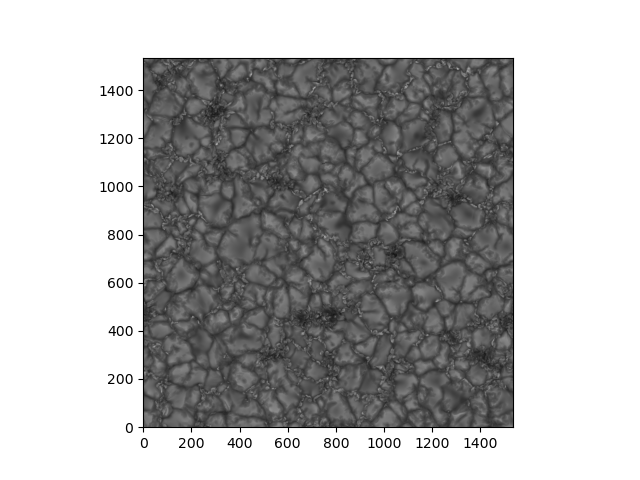

In [3]:
#Wavelength index 200 is in the continuum

# ndat is normalized data
ndat = tess.normalize_data( sf['I'][:,:,200])
fig2, ax2 = plt.subplots()
ax2.imshow(ndat, origin='lower',cmap=plt.cm.gray)

Other properties of the stokes data, but we mostly won't use it after this:

In [4]:
sf.keys(), sf['I']

(<KeysViewHDF5 ['I', 'Q', 'U', 'V', 'lambda']>,
 <HDF5 dataset "I": shape (1536, 1536, 276), type "<f4">)

In [5]:
sf.close()

## load horizontal velocities and vertical magnetic field from the muram data: vx, vy, and bz.  

- vx = subdomain2
- vy = subdomain3
- bz = subdomain5

In [6]:
vx = tess.load_muram_subfield('subdomain_2.070857')
vy = tess.load_muram_subfield('subdomain_3.070857')
bz = tess.load_muram_subfield('subdomain_5.070857')

## Tesselate the continuum image (label every granule)

The following uses a few routines from `scikit.image` to isolate the granules.  Based on the watershed algorithm

Run the routitne from the granule-finding code, operating on normalized data ndat.
Steps in the algorithm:
1. find local maxima in the normalized intensity field (separated by at least 8 pixels), and label them
2. set all pixels downhill from each maxima to have the same label as the maxima (downhill tesselation).<br>
   This is limited by the threshold, set here to a normalized value of 0.3
3. Get the 'regionproperties' of each labeled region (pixel location, moments, boundary, etc.)  uses `scikit.measure.regionprops`
   

In [7]:
props, labels = tess.get_props_from_ndat(ndat,threshold=0.3)

The tesselated regions that were made in my previous step can contain holes (non-simply connected spaces).  This messes up my method for extracting the boundary pixels, so let's make a new set of labels to fill in the holes

Fill in all the holes in the region labels.

In [8]:
newlabels = np.zeros_like(labels)
for pp in tqdm(props):
    bb = pp.bbox
    newlabels[bb[0]:bb[2],bb[1]:bb[3]] += pp.image_filled*pp.label

  0%|          | 0/916 [00:00<?, ?it/s]

Plot the old and new labels

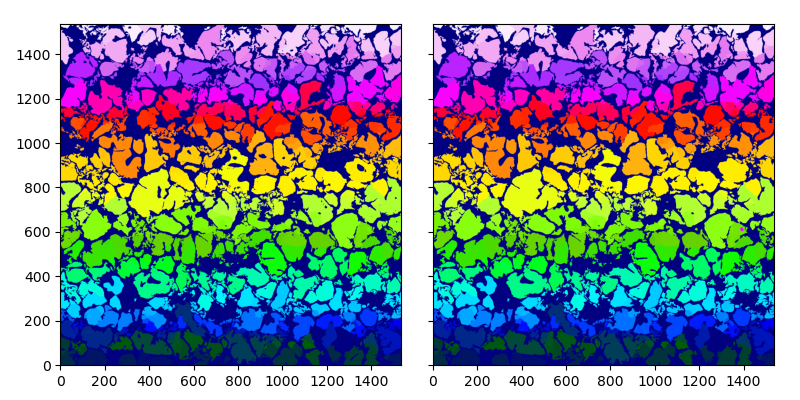

In [9]:
fig3, ax3 = plt.subplots(ncols = 2, figsize=(8,4),sharex=True, sharey=True)
im30 = ax3[0].imshow(labels, cmap = plt.cm.gist_ncar, origin='lower')
im31 = ax3[1].imshow(newlabels, cmap = plt.cm.gist_ncar, origin='lower')
fig3.tight_layout()

Now recalculate the all the propoerties of each region in the newly labeled image

In [10]:
nprops = regionprops(newlabels,intensity_image=ndat)

We might also want to grow the regions until we've expanded to fill all the space of the lanes.  That would allow us to search for things like corrugated edges in stages, moving further out from the center of granules

In [11]:
elabels = expand_labels(newlabels,distance=2)

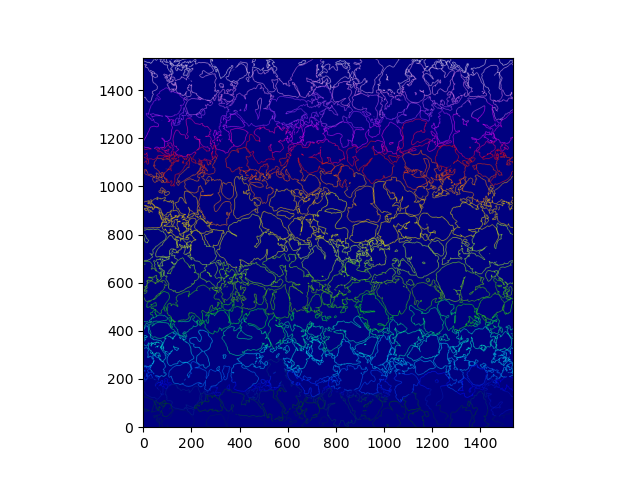

In [12]:
ff, aa = plt.subplots()
aa.imshow(elabels-newlabels,origin='lower', cmap=plt.cm.gist_ncar)

Might also be useful to just aggressively fill the space, and then work with regions labels that way:

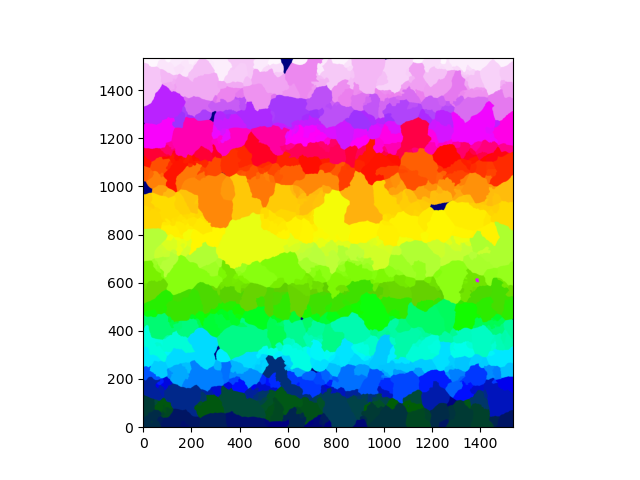

In [13]:
fb, ab = plt.subplots()
ab.imshow(expand_labels(newlabels,distance=30),origin='lower', cmap=plt.cm.gist_ncar)

## Get the coordinates of each granular boundary

Now I need the pixel locations of each boundary.  There's a package here: https://github.com/theobdt/boundary_tracing.  It's based on the moore neighborhood of each pixel.  See also https://stackoverflow.com/questions/25379752/how-can-i-extract-the-boundary-curve-of-an-image-region-in-scikit-image

Here's how I get the coordinates of one of the granule boundaries.  Also shown is the transform from python-standard [y,x] ordering to [x,y] ordering of the array.

In [14]:
coords = tess.boundary_tracing(nprops[0])[:, ::-1]  # (y, x) --> (x, y)

It may be desireable to make the boundary periodic by appending the pixel location at the beginning of the loop to the end of the loop (very much task dependent)

In [15]:
coords_closed = np.vstack((coords,coords[0,:])) # close the loop

  0%|          | 0/913 [00:00<?, ?it/s]

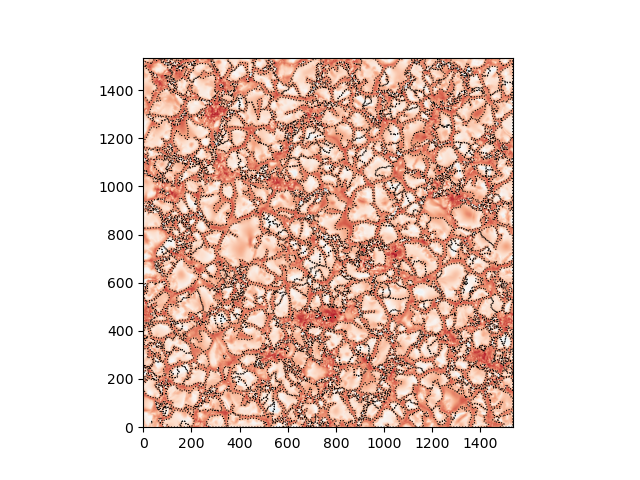

In [16]:
fig4,ax4 = plt.subplots()
#ax.streamplot(np.arange(500),np.arange(500), (gradI[0]/absgradI)[500:1000,200:700],(gradI[1]/absgradI)[500:1000,200:700])
im4 = ax4.imshow(ndat, origin='lower', cmap=plt.cm.RdBu)

for pp in tqdm(nprops):
    # this should run in a couple seconds.  If it doesn't, it's probably because there's a lingering hole some where that 
    # causing the boundary tracing algorithm to fail.  Could check for Euler characteristic=0 (pp.euler_number), but 
    # I might want to dig more into how that is calculated on the binary image.
    coords = tess.boundary_tracing(pp)[:, ::-1]  # (y, x) --> (x, y)
    ax4.plot(coords[:,0], coords[:,1],color='black', linestyle=':',linewidth=0.8)

# Below this are some older notes I wrote up, calculating circulation around granules a couple different ways (some better than others)

## Circulation

I want something like circulation.  The curl of $v_\perp$ is the vorticity. At first I thought I might dot vorticity into the contours of the intensity field, like so 
<br>$\hat{z}\times\nabla (I)=\partial_yI\hat{x} -\partial_x I\hat{y}$  
<br> But I don't think that's what I want.  Instead I want something like this:  $\hat{z}\times\frac{\nabla(I)}{\lvert \nabla(I)\rvert}\cdot \vec{v}_\perp$.  That gives the counterclockwise circulation of the velocity field along contours of the intensity field.

Then I want to look for strong gradients of the resulting field, and select the regions that have close to zero net local circulation.  That should select out regions with strong sheer.  UPDATE: no longer think this idea is correct, but I'm leaving the comment in here.

In [17]:
# contours of I:
gradI = np.gradient(ndat)
absgradI = np.sqrt(gradI[0]**2 + gradI[1]**2)
#curlvperp = np.gradient(vy, axis=1) - np.gradient(vx, axis=0)
circulation = (gradI[1]*vx[64]-gradI[0]*vy[64])/absgradI

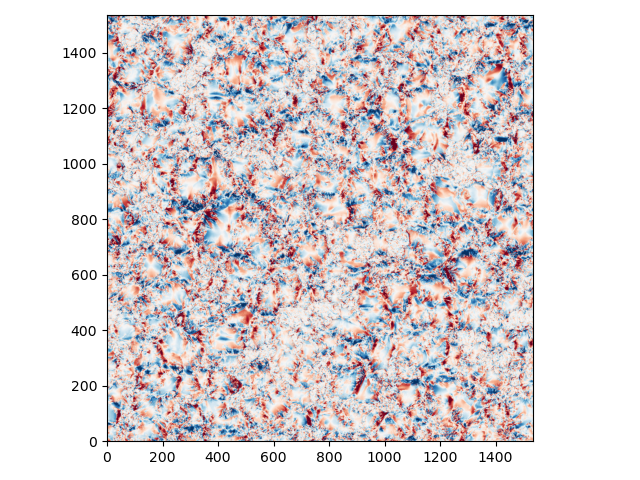

In [18]:
plt.close(5)
fig,ax = plt.subplots()
im = ax.imshow(circulation, origin='lower', aspect='equal', cmap=plt.cm.RdBu)
im.set_clim(-5e5,5e5)
fig.tight_layout()

Outline each identified granule with its bounding curve on the circulation:

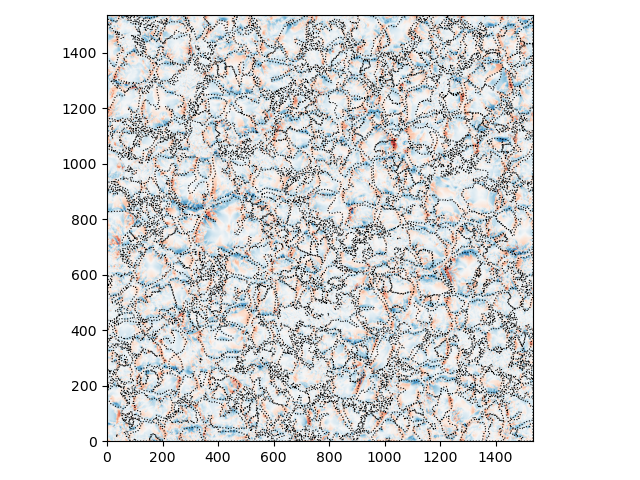

In [19]:
plt.close(6)
fig,ax = plt.subplots()
#ax.streamplot(np.arange(500),np.arange(500), (gradI[0]/absgradI)[500:1000,200:700],(gradI[1]/absgradI)[500:1000,200:700])
im2 = ax.imshow(circulation, origin='lower', cmap=plt.cm.RdBu)

for pp in nprops:
    coords = tess.boundary_tracing(pp)[:, ::-1]  # (y, x) --> (x, y)
    ax.plot(coords[:,0], coords[:,1],color='black', linestyle=':',linewidth=0.8)
    
fig.tight_layout()

I can use the (filled-in, no holes) regions to calculate the net circulation in each granule.    Here the calculation is done using a simple summation over all pixels within the granule:

In [20]:
netcirc = np.zeros_like(circulation)
for pp in nprops:
    # coordinations
    rr,cc = pp.coords[:,0],pp.coords[:,1]
    netcirc[rr,cc] = np.sum(circulation[rr,cc])

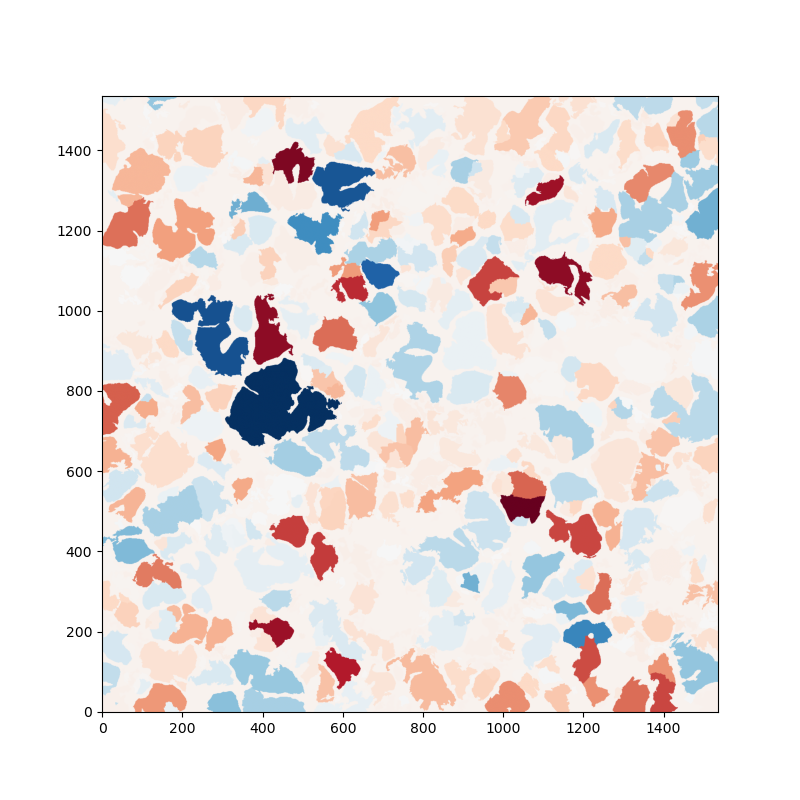

In [21]:
figc, axc = plt.subplots(figsize=(8,8))
imc = axc.imshow(netcirc,origin='lower', cmap = plt.cm.RdBu)
fig.tight_layout()

Now do the same, but get the true circulation around the boundary of each granule.  This is defined as the integral of v.dl about the closed curve describing the granule boundary.

I will also compare this to the integral of vorticity within the granule.  The two calculations should be equivalent, by Stokes' theorem: $\int_{\partial S} \mathbf{v}\cdot d\mathbf{l} = \int_{S} \nabla\times\mathbf{v}\cdot d\mathbf{S}$

The muram derivative is the 4th-order stencil $\partial_x f \bigr\vert_i \approx \frac{1}{12\Delta x}(f_{i-2}-8f_{i-1}+8 f_{i+1}-f_{i+2})$

In [22]:
ddx = lambda x: 1./12*(np.roll(x,shift=2,axis=1)-8*np.roll(x,shift=1,axis=1)+8*np.roll(x,shift=-1,axis=1)-np.roll(x,shift=-2,axis=1))
ddy = lambda x: 1./12*(np.roll(x,shift=2,axis=0)-8*np.roll(x,shift=1,axis=0)+8*np.roll(x,shift=-1,axis=0)-np.roll(x,shift=-2,axis=0))

The vorticity is then

In [23]:
vorticity = ddx(vy[64])-ddy(vx[64])

Below is the main cell in this section.  I get the boundary of each granule and set up the directed curve (CCW) along the boundary.  That uses the `image_tracing.boundary_tracing` routine I found that determines the CCW-directed curve of the boundary, given a `scikit-image.measure.regionprops` object.

I then integrate $v.dl$ along that curve to get the real circulation of the velocity field around the granule cell.  I perform two estimates of the integral, the first using simpsons rule to integrate v.dl about the curve, the second as a simple summation of each segment.  

I also compare both of those circulation estimates with what should be the same thing, the integral (via summation) of the vorticity over the full area of each granule.

In [24]:
boundary_circulation = np.zeros_like(circulation) # integral over closed curve using simpson's run
boundary_circulationsum = np.zeros_like(circulation) # simple summation over the same closed curve
vorticity_sum = np.zeros_like(circulation) # summation of the vorticity within each granule...should be equal to the above.
bcirc = {}
for pp in nprops:
    coords = tess.boundary_tracing(pp)
    coords = np.vstack((coords,coords[0,:])) # close the loop
    coordsp1 = np.roll(coords, shift=-1, axis=0)
    coordsxy=coords[:, ::-1] # reverse order so the arrays are ordered (x,y) instead of (y,x)
    coordsxyp1 = np.roll(coordsxy, shift=-1, axis=0)
    ds = coordsxyp1-coordsxy
    th = np.atan2(ds[:,1],ds[:,0]) # cosine angles of each step

    xstep = np.cos(th)
    ystep = np.sin(th)
    
    tcirc = xstep*(vx[64][coords[:,0],coords[:,1]]+ vx[64][coordsp1[:,0],coordsp1[:,1]])/2\
            + ystep*(vy[64][coords[:,0],coords[:,1]]+ vy[64][coordsp1[:,0],coordsp1[:,1]])/2
    dl = np.sqrt(ds[:,0]**2+ds[:,1]**2)
    bc = simpson(tcirc, x=np.cumsum(dl))
    bcirc[pp.label] = bc
    rr,cc = pp.coords[:,0],pp.coords[:,1]
    boundary_circulation[rr,cc] = bc
    boundary_circulationsum[rr,cc] = np.sum(tcirc*dl)
    vorticity_sum[rr,cc] = np.sum(vorticity[rr,cc])

Compare net and boundary circulation:

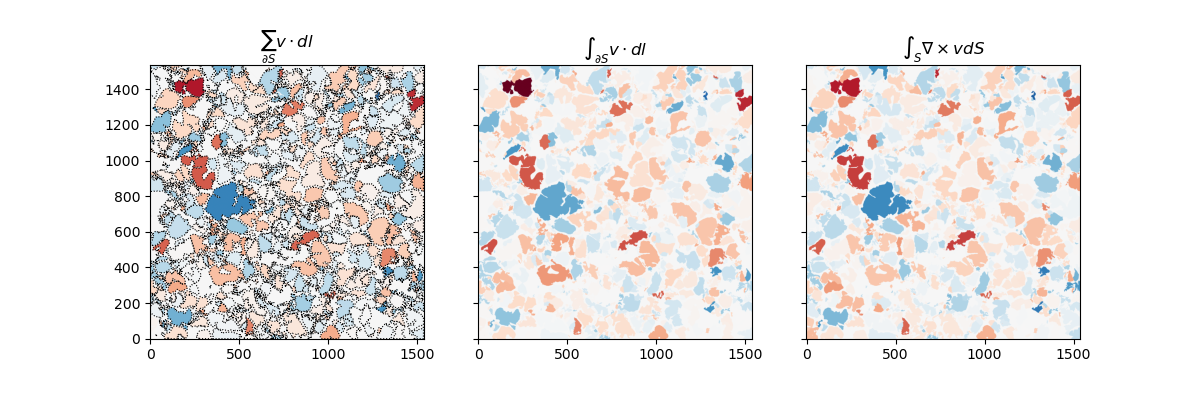

In [25]:
plt.close(8)
figc, axc = plt.subplots(ncols=3, sharex=True, sharey=True,figsize=(12,4))
imc0 = axc[0].imshow(boundary_circulationsum,origin='lower', cmap = plt.cm.RdBu)
imc1 = axc[1].imshow(boundary_circulation,origin='lower', cmap = plt.cm.RdBu)
imc2 = axc[2].imshow(vorticity_sum,origin='lower', cmap = plt.cm.RdBu)
imc0.set_clim(-3e7,3e7) # approximate min-max values
imc1.set_clim(-3e7,3e7)
imc2.set_clim(-3e7,3e7)
for pp in nprops:
    coords = tess.boundary_tracing(pp)[:, ::-1]  # (y, x) --> (x, y)
    axc[0].plot(coords[:,0], coords[:,1], linestyle=':', color='black',lw=0.8)

axc[0].set_title(r'$\sum_{\partial S}v\cdot dl$')
axc[1].set_title(r'$\int_{\partial S}v\cdot dl$')
axc[2].set_title(r'$\int_{S}\nabla\times v dS$')

fig.tight_layout()

The results are comparable for all three methods.  They also roughly correspond to the "net circulation" I calculated above calculated above, by summing the velocity field dotted into the tangent of the intensity field within each granule.

Places of high velocity shear flow should be locations where the circulation of adjacent granules is in the same direction.  Not sure how well that works out in practice.  But what is interesting is that I am finding net circulation around the granules.

## ratio of horizontal to vertical velocity

In [26]:
# load vz:
vz = tess.load_muram_subfield('subdomain_1.070857')

In [27]:
vt = np.sqrt(vx**2+vy**2)

In [28]:
ratio = vt/vz

In [29]:
ratio.shape

(128, 1536, 1536)

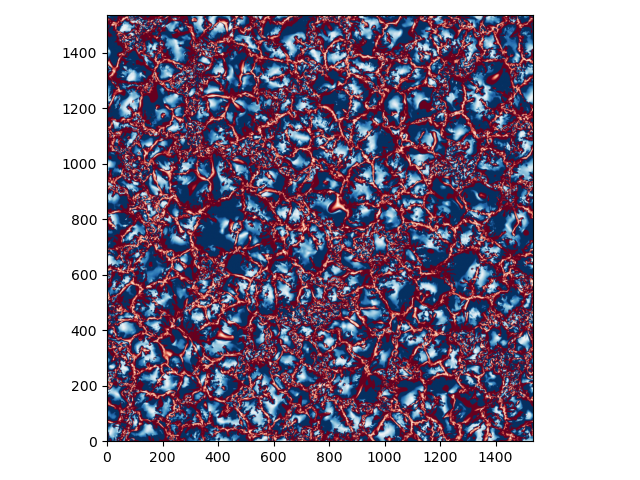

In [30]:
plt.close(11)
fig, ax = plt.subplots()
im = ax.imshow(ratio[64],origin='lower', cmap=plt.cm.RdBu)
fig.tight_layout()
im.set_clim(-1,1)

So, the granular lanes are compact, and best seclected out as the locations where negative vertical flows dominate horizontal flows, by a factor of, say, 2.

The greatest *shear* might be in the vertical flows, not the horizontal flows.  But it's still localized to the lanes.

# Lanes...are labels <1

I can also do the following to get the intergranular lanes (and pores).  Not sure I want this, yet

In [31]:
lanes = labels <1

Image of the mask separating inter-granular lanes from granules

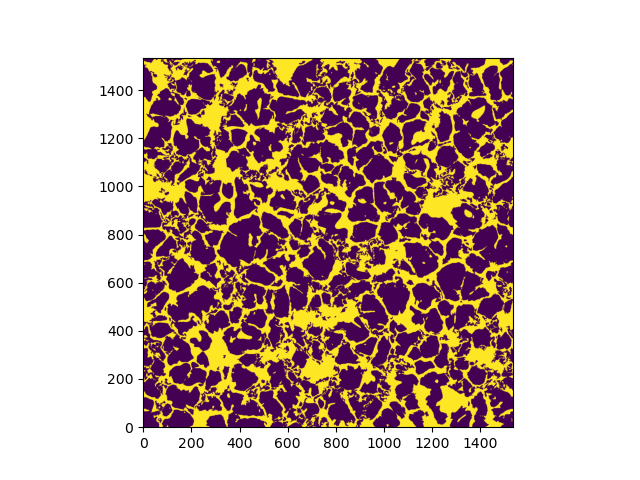

In [32]:
plt.close(3)
fig, ax = plt.subplots(ncols=1)
im = ax.imshow(lanes,origin='lower')